## Name: Indian Rural Road Networks
### Date: November 13, 2025
### Purpose: Mapping SHRUG data by district over all current road networks and PMGSY III road building projects to understand the impact of PMGSY I and II road building projects on rural development metrics. This piece of code attempts to map only Chhattisgarh historical road networks by district to be later replicated over other states as well.

In [2]:
#conda create -n geo python=3.11
#conda activate geo
#conda install -c conda-forge geopandas

In [3]:
import sys
print(sys.executable)

c:\Users\kavin\AppData\Local\Python\pythoncore-3.14-64\python.exe


This folder includes the road network shapefiles for Chhattisgarh and the SHRUG district data 

In [4]:
cd C:\Users\kavin\Downloads\Chhattisgarh_roads


C:\Users\kavin\Downloads\Chhattisgarh_roads


In [5]:
! pip install geopandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\kavin\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 26065 entries, 0 to 26064
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ER_ID       26065 non-null  int64   
 1   STATE_ID    26065 non-null  int64   
 2   BLOCK_ID    26065 non-null  int64   
 3   DISTRICT_I  26065 non-null  int64   
 4   DRRP_ROAD_  26065 non-null  str     
 5   RoadCatego  26065 non-null  str     
 6   RoadName    26065 non-null  str     
 7   RoadOwner   26065 non-null  str     
 8   geometry    26065 non-null  geometry
dtypes: geometry(1), int64(4), str(4)
memory usage: 1.8 MB
None
     ER_ID  STATE_ID  BLOCK_ID  DISTRICT_I  DRRP_ROAD_ RoadCatego  \
0   893726         7      6085         448     VR-1239     RR(VR)   
1   893728         7      6085         448     VR-1241     RR(VR)   
2   904308         7      6085         448  RR(VR)1301     RR(VR)   
3  1313654         7      7022         628   RR(V

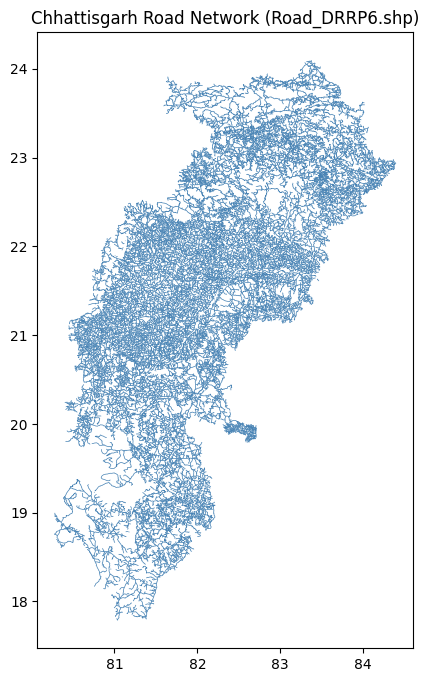

In [8]:
import geopandas as gpd
import os
import matplotlib.pyplot as plt


# Path to your shapefile
shapefile_path =  r"Road_DRRP6.shp"

# Load the shapefile
roads = gpd.read_file(shapefile_path)

# Display basic info
print("✅ Shapefile loaded successfully!")
print(roads.info())
print(roads.head())

# Plot the shapefile
roads.plot(figsize=(10, 8), color='steelblue', linewidth=0.5)
plt.title("Chhattisgarh Road Network (Road_DRRP6.shp)")
plt.show()


# Districts Shrid 

Using shapefile path: shrug_data\shrug_data\shrug-pc11dist-poly-shp\district.shp
✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pc11_s_id  641 non-null    str     
 1   pc11_d_id  641 non-null    str     
 2   d_name     640 non-null    str     
 3   geometry   641 non-null    geometry
dtypes: geometry(1), str(3)
memory usage: 20.2 KB
None
  pc11_s_id pc11_d_id        d_name  \
0        24       468       Kachchh   
1        24       469  Banas Kantha   
2        24       470         Patan   
3        24       471      Mahesana   
4        24       472  Sabar Kantha   

                                            geometry  
0  MULTIPOLYGON (((70.45008 23.01226, 70.44904 23...  
1  MULTIPOLYGON (((71.24964 24.20926, 71.24207 24...  
2  MULTIPOLYGON (((71.42507 23.96967, 71.42497 23...  
3  POLYGON ((72.79

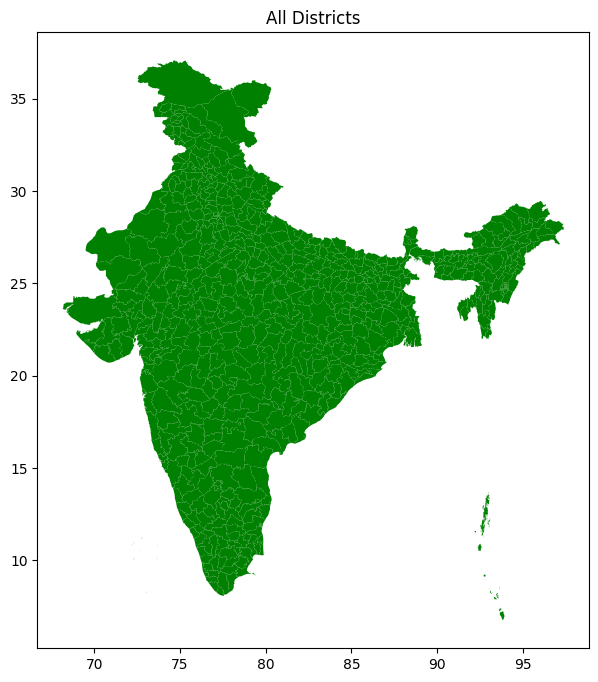

In [9]:
# Path to the Indian district shapefile
district_path = r"shrug_data\shrug_data\shrug-pc11dist-poly-shp\district.shp"

# Check path
print("Using shapefile path:", district_path)

# Load the shapefile
district = gpd.read_file(district_path)

# Display basic info
print("✅ Shapefile loaded successfully!")
print(district.info())
print(district.head())

# Plot the shapefile
district.plot(figsize=(10, 8), color='green', linewidth=0.5)
plt.title("All Districts")
plt.show()


## Matching Road Networks to Chhatisgarh district to reduce playing field down to only one district and make matching roads before and after 2015 easier. 

In [10]:
roads.head()

,ER_ID,STATE_ID,BLOCK_ID,DISTRICT_I,DRRP_ROAD_,RoadCatego,RoadName,RoadOwner,geometry
0,893726,7,6085,448,VR-1239,RR(VR),Nakti K to Madhi,CRRDA,"LINESTRING (81.8083 21.45909, 81.80828 21.4591..."
1,893728,7,6085,448,VR-1241,RR(VR),Kundru to Nakti K,RD,"LINESTRING (81.7887 21.47855, 81.78971 21.4779..."
2,904308,7,6085,448,RR(VR)1301,RR(VR),Alda to Nawapara Road,RD,"LINESTRING (81.90943 21.5963, 81.90926 21.5959..."
3,1313654,7,7022,628,RR(VR)125,RR(VR),Kodwabani to Guruwaindabri,RWD,"LINESTRING (81.71901 22.13687, 81.71899 22.136..."
4,888184,7,655,58,03T04,NH,Nizamabad to Jagdalpur Road Km 442 to km 462,PWD,"LINESTRING (81.46339 18.96331, 81.46837 18.968..."


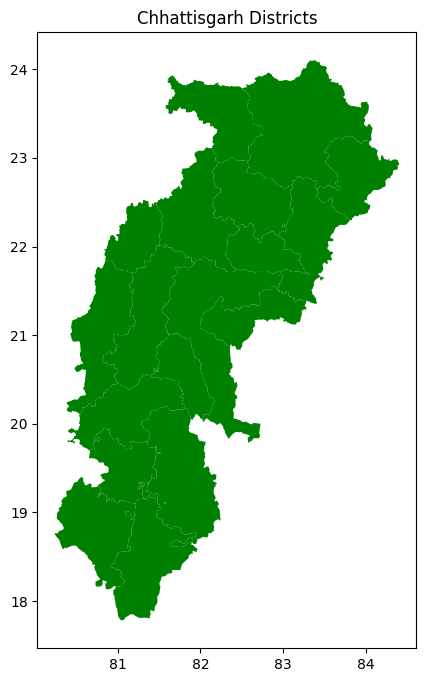

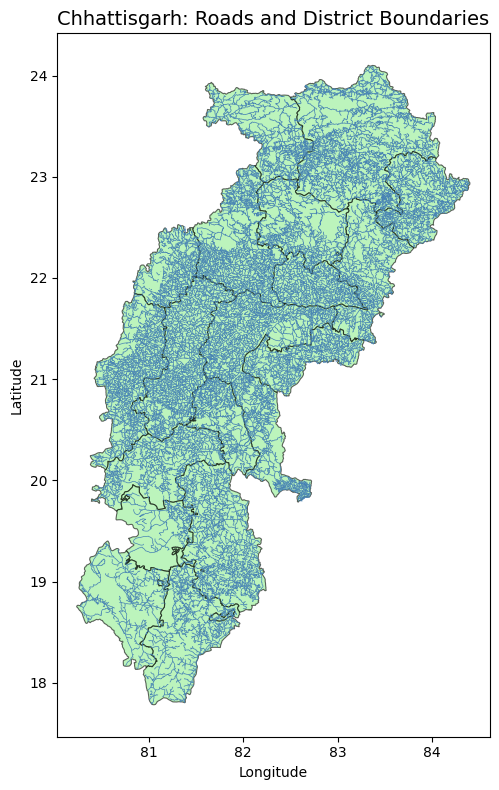

In [11]:
# Filter to state 22 (Chhattisgarh)
Chhattisgarh_d = district[district['pc11_s_id'] == '22'] 

# Plot the shapefile
Chhattisgarh_d.plot(figsize=(10, 8), color='green', linewidth=0.5)
plt.title("Chhattisgarh Districts")
plt.show()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot districts (green background)
Chhattisgarh_d.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
roads.plot(ax=ax, color='steelblue', linewidth=0.5)

# Add title and clean layout
ax.set_title("Chhattisgarh: Roads and District Boundaries", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()
#District 400--- Koriya

# Ensure same CRS
roads = roads.to_crs(Chhattisgarh_d.crs)

## Shrid Keys for 2011 and 2001

In [12]:
# Load district mapping keys to show which villages (shrids) in which districts,
# and match 2022 districts to 2011 districts
import pandas as pd

# Paths to the keys
pc11_key_path = r"shrug_data\shrug_data\shrug-pc-keys-csv\shrid_pc11dist_key.csv"
pc01_key_path = r"shrug_data\shrug_data\shrug-pc-keys-csv\shrid_pc01dist_key.csv"

# Load the keys
pc11_key = pd.read_csv(pc11_key_path)
pc01_key = pd.read_csv(pc01_key_path)


Reading Shrid2
- State code → 01 (Chattisgarh)
- District code → ie 01
- Sub-district / Tehsil / Taluka code → ie 01
    Smaller administrative unit within the district
- Village / Census block / Ward code → ie 0002
    Even smaller unit within the sub-district
- Unique identifier → 00008200
    Globally unique ID for this spatial unit in the shapefile

In [13]:
pc11_key.head()

,shrid2,pc11_state_id,pc11_district_id
0,11-01-001-00001-000001,1,1
1,11-01-001-00001-000002,1,1
2,11-01-001-00001-000005,1,1
3,11-01-001-00001-000006,1,1
4,11-01-001-00001-000007,1,1


### Mapping Roads

In [14]:
# Merge on shrid to get mapping from pc01_d_id to pc11_d_id
mapping_df = pc11_key[['shrid2', 'pc11_district_id']].merge(pc01_key[['shrid2', 'pc01_district_id']], on='shrid2', how='inner')

# Create a dictionary for mapping pc01_d_id to pc11_d_id
pc01_to_pc11 = dict(zip(mapping_df['pc01_district_id'].astype(str), mapping_df['pc11_district_id'].astype(str)))

# Now, assign pc11_d_id to roads based on DISTRICT_I 
roads['pc11_d_id'] = roads['DISTRICT_I'].astype(str).map(pc01_to_pc11)

# Check for any unmapped
unmapped = roads['pc11_d_id'].isna().sum()
print(f"Unmapped roads: {unmapped}")
print(roads[['DISTRICT_I', 'pc11_d_id']].head())

Unmapped roads: 25233
   DISTRICT_I pc11_d_id
0         448       NaN
1         448       NaN
2         448       NaN
3         628       NaN
4          58       188


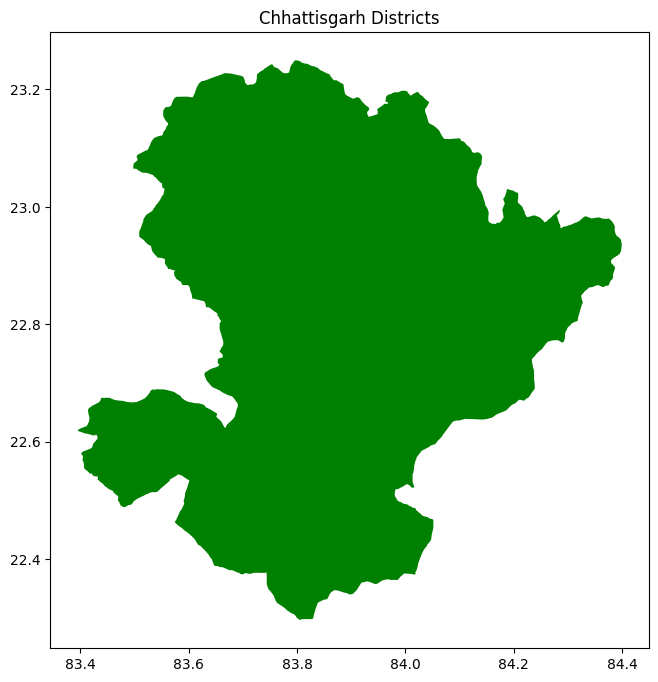

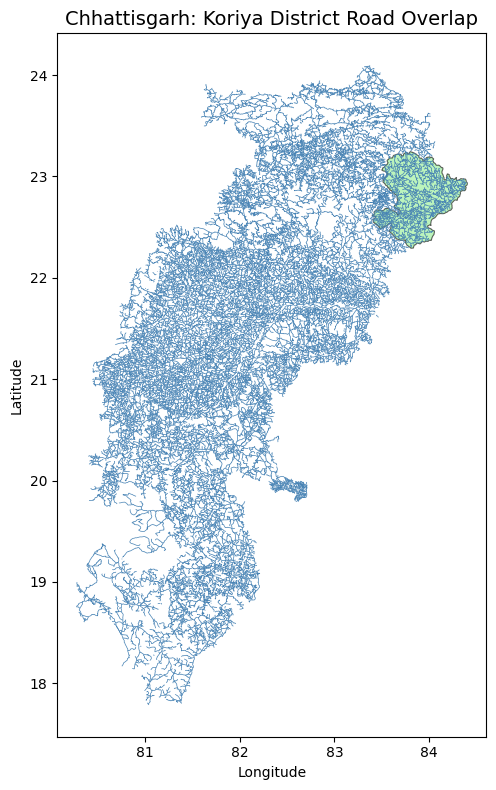

In [15]:
# Filter to district 402 (Chhattisgarh district Jashpur)
Chhattisgarh_402 = district[district['pc11_d_id'] == '402']

# Plot the shapefile
Chhattisgarh_402.plot(figsize=(10, 8), color='green', linewidth=0.5)
plt.title("Chhattisgarh Districts")
plt.show()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot districts (green background)
Chhattisgarh_402.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
roads.plot(ax=ax, color='steelblue', linewidth=0.5)

# Add title and clean layout
ax.set_title("Chhattisgarh: Koriya District Road Overlap", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Ensure same CRS
roads = roads.to_crs(Chhattisgarh_402.crs)


In [16]:
'''We are trying to consider which roads in the current 2022 system 
match with which districts in 2011 (which have different district numbers) '''
#changing the road data to make state 7= state 22 
roads["STATE_ID"] = 22
roads["STATE_ID"]
# Spatial join: assign each road the district id
roads_matched = gpd.sjoin(roads, Chhattisgarh_d[['pc11_d_id','d_name', 'geometry']])

# Save
roads_matched.to_file('Road_DRRP6_matched.shp')

C:\Users\kavin\AppData\Local\Temp\ipykernel_30736\731372897.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  roads_matched.to_file('Road_DRRP6_matched.shp')
c:\Users\kavin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'pc11_d_id_left' to 'pc11_d_id_'
  ogr_write(
c:\Users\kavin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
c:\Users\kavin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'pc11_d_id_right' to 'pc11_d_i_1'
  ogr_write(


In [17]:
roads_matched["pc11_d_id_right"]. value_counts()

pc11_d_id_right
401    3081
410    2808
409    2277
408    2171
406    2126
403    1686
414    1557
411    1498
402    1471
405    1242
412    1207
407    1074
413     999
404     976
416     943
400     876
417     378
415     252
Name: count, dtype: int64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 26622 entries, 0 to 26064
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ER_ID            26622 non-null  int64   
 1   STATE_ID         26622 non-null  int64   
 2   BLOCK_ID         26622 non-null  int64   
 3   DISTRICT_I       26622 non-null  int64   
 4   DRRP_ROAD_       26622 non-null  str     
 5   RoadCatego       26622 non-null  str     
 6   RoadName         26622 non-null  str     
 7   RoadOwner        26622 non-null  str     
 8   geometry         26622 non-null  geometry
 9   pc11_d_id_left   866 non-null    str     
 10  index_right      26622 non-null  int64   
 11  pc11_d_id_right  26622 non-null  str     
 12  d_name           26622 non-null  str     
dtypes: geometry(1), int64(5), str(7)
memory usage: 2.8 MB
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1471 entries, 7 to 26058
Data columns (total 13 columns):
 #   Column  

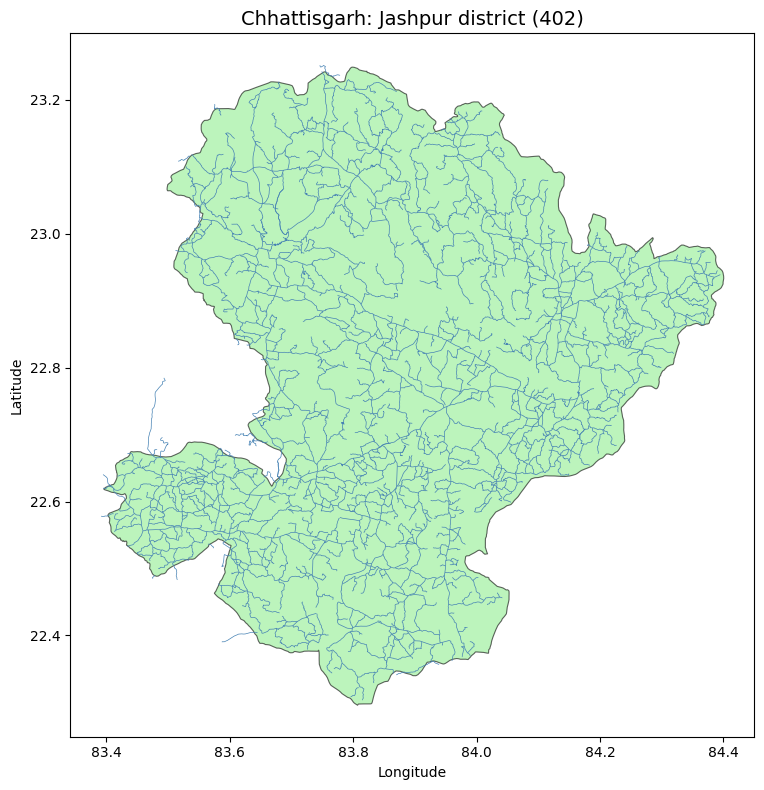

<Figure size 640x480 with 0 Axes>

In [18]:
#roads.info()
roads_matched.info()
#roads_400 = roads[roads["DISTRICT_I"] == 400] #0 values in district 400
roads_402=roads_matched[roads_matched["pc11_d_id_right"] == "402"] #1471 values in district 402 in matched
roads_402.info()

#roads_matched["pc11_d_id"].unique()
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot districts (green background)
Chhattisgarh_402.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
roads_402.plot(ax=ax, color='steelblue', linewidth=0.5)

# Add title and clean layout
ax.set_title("Chhattisgarh: Jashpur district (402)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Ensure same CRS
roads = roads.to_crs(Chhattisgarh_402.crs)

output_path = r"C:\Users\kavin\Downloads\Chhattisgarh_roads\shrug_data\shrug_data\chhattisgarh_district_402.png"
plt.savefig(output_path, dpi=300)  # dpi=300 for high resolution


using shrid_pc11dist_key to connect the pmgsy data to the district and road name to the current road network.

In [19]:
# Path to the csv
pmgsy_path = r"shrug_data\shrug_data\shrug-pmgsy-csv\pmgsy_2015_shrid.csv"

# Check path
print("Using shapefile path:", pmgsy_path)

# Load the csv
pmgsy = gpd.read_file(pmgsy_path)

# Display basic info
print("✅ Shapefile loaded successfully!")
print(pmgsy.info())


Using shapefile path: shrug_data\shrug_data\shrug-pmgsy-csv\pmgsy_2015_shrid.csv
✅ Shapefile loaded successfully!
<class 'pandas.DataFrame'>
RangeIndex: 589090 entries, 0 to 589089
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   shrid2                   589090 non-null  str  
 1   road_award_date_new      589090 non-null  str  
 2   road_award_date_upg      589090 non-null  str  
 3   road_comp_date_new       589090 non-null  str  
 4   road_comp_date_upg       589090 non-null  str  
 5   road_comp_date_stip_new  589090 non-null  str  
 6   road_comp_date_stip_upg  589090 non-null  str  
 7   road_sanc_year_new       589090 non-null  str  
 8   road_sanc_year_upg       589090 non-null  str  
 9   road_length_new          589090 non-null  str  
 10  road_length_upg          589090 non-null  str  
 11  road_cost_new            589090 non-null  str  
 12  road_cost_upg            589090 non-nul

In [20]:
roads_matched["RoadName"]

0                                     Nakti K to Madhi
1                                    Kundru to Nakti K
2                                Alda to Nawapara Road
3                           Kodwabani to Guruwaindabri
4         Nizamabad to Jagdalpur Road Km 442 to km 462
                             ...                      
26060    WADRAFNAGAR BALANGI  ROAD  TO  HARIGAWAN KHAS
26061                                  T07 to Bharsela
26062                               Kumhari to Kohraud
26063                      03T011 Chamap to Bharuwadih
26064                     03T011 (4/2Km) to Khamhariya
Name: RoadName, Length: 26622, dtype: str

In [21]:
pmgsy = pmgsy.replace(r'^\s*$', None, regex=True)
#pmgsy_filtered = pmgsy.dropna(how='all')
# Get all columns except 'shrid2'
other_cols = [c for c in pmgsy.columns if c != "shrid2"]

# Drop rows where all other columns are NaN
pmgsy_filtered = pmgsy.dropna(subset=other_cols, how="all")

print("Before:", pmgsy.shape)
print("After:", pmgsy_filtered.shape)

#pmgsy_filtered = pmgsy[pmgsy["road_award_date_new"].notnull()]
pmgsy_filtered.head()

Before: (589090, 19)
After: (146262, 19)


,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,road_length_upg,road_cost_new,road_cost_upg,road_cost_sanc_new,road_cost_sanc_upg,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg
1652,11-01-001-00001-000002,2006-10-24,NaN,2010-06-01,NaN,2007-11-07,NaN,2004.0,NaN,5.5,NaN,170.1,NaN,181.71,NaN,0.0,NaN,Dett. Bridge - Keran,NaN
1653,11-01-001-00001-000005,2006-10-24,NaN,2010-06-01,NaN,2007-11-07,NaN,2004.0,NaN,5.5,NaN,170.1,NaN,181.71,NaN,0.0,NaN,Dett. Bridge - Keran,NaN
1655,11-01-001-00001-000007,2011-04-20,NaN,NaN,NaN,NaN,NaN,2007.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1656,11-01-001-00001-000008,2011-04-20,NaN,NaN,NaN,NaN,NaN,2007.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1672,11-01-001-00001-000024,2008-10-02,2010-12-08,2010-10-01,2013-11-01,2009-04-14,2012-05-26,2003.0,2007.0,3.4,13.0,113.13,1218.6,101.99,1626.26,0.0,0.0,NaN,Gungbugh - Chandagam


#### Current Network

In [22]:
#district 402
pmgsy_currentnetwork=pmgsy_filtered.merge(roads_402, left_on="road_name_new", right_on="RoadName", how="left")
pmgsy_currentnetwork.head()

,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,...,DISTRICT_I,DRRP_ROAD_,RoadCatego,RoadName,RoadOwner,geometry,pc11_d_id_left,index_right,pc11_d_id_right,d_name
0,11-01-001-00001-000002,2006-10-24,NaN,2010-06-01,NaN,2007-11-07,NaN,2004.0,NaN,5.5,...,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,11-01-001-00001-000005,2006-10-24,NaN,2010-06-01,NaN,2007-11-07,NaN,2004.0,NaN,5.5,...,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,11-01-001-00001-000007,2011-04-20,NaN,NaN,NaN,NaN,NaN,2007.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,11-01-001-00001-000008,2011-04-20,NaN,NaN,NaN,NaN,NaN,2007.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,11-01-001-00001-000024,2008-10-02,2010-12-08,2010-10-01,2013-11-01,2009-04-14,2012-05-26,2003.0,2007.0,3.4,...,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN


# Understanding PMGSY I (Proposed plans)

In [23]:
#PMGSY 3 started in 2015, these roads will include those added after 2015. 
#There are alot of nans in "shrug_data\shrug_data\shrug-pmgsy-csv\pmgsy_2015_shrid.csv"
pmgsy.notna().sum() #about 90,000 not nans
pmgsy.isna().sum()#500,000 nans 

#drop rows with all nans
pmgsy_shrid_clean= pmgsy.dropna(subset=["road_award_date_new", "road_sanc_year_new"], thresh=1)
pmgsy_shrid_clean.isna().sum() #all below 100,000

shrid2                         0
road_award_date_new        10746
road_award_date_upg        98647
road_comp_date_new         28448
road_comp_date_upg         98565
road_comp_date_stip_new    32041
road_comp_date_stip_upg    98645
road_sanc_year_new             0
road_sanc_year_upg         98565
road_length_new            28904
road_length_upg            98565
road_cost_new              28904
road_cost_upg              98565
road_cost_sanc_new         28904
road_cost_sanc_upg         98565
road_cost_state_new        28904
road_cost_state_upg        98565
road_name_new              29745
road_name_upg              99364
dtype: int64

✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   MRL_ID      1676 non-null   int64   
 1   STATE_ID    1676 non-null   int64   
 2   DISTRICT_I  1676 non-null   int64   
 3   LGD_STATE   1676 non-null   int64   
 4   LGD_DISTRI  1676 non-null   int64   
 5   BLOCK_ID    1676 non-null   int64   
 6   CN_CODE     1509 non-null   float64 
 7   PROPOSED_L  1676 non-null   float64 
 8   WORK_NAME   1659 non-null   str     
 9   IMS_YEAR    1676 non-null   int64   
 10  IMS_BATCH   1676 non-null   int64   
 11  Proposal_T  1676 non-null   str     
 12  geometry    1676 non-null   geometry
dtypes: float64(2), geometry(1), int64(8), str(2)
memory usage: 170.3 KB
None
   MRL_ID  STATE_ID  DISTRICT_I  LGD_STATE  LGD_DISTRI  BLOCK_ID   CN_CODE  \
0   49645         7         625         22         649      7010  

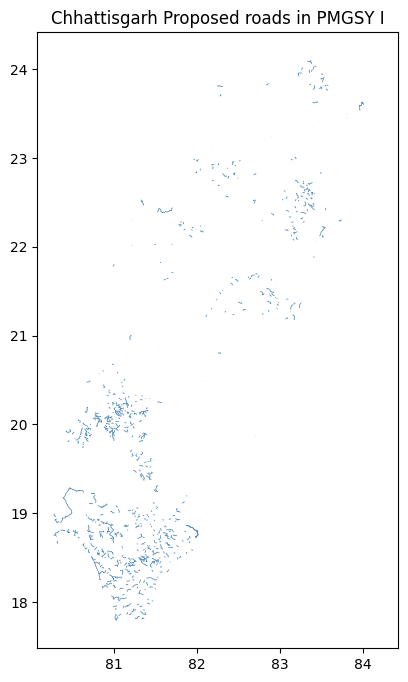

In [24]:
# Path to your shapefile (this is only the chhattisgarh roads, id=22)
pmgsy1_chh_shp =  r"C:\Users\kavin\Downloads\PMGSY-I-6states-20260211T003432Z-1-001\PMGSY-I-6states\Proposal_PMGSY-I_Chhattisgarh\Proposal_PMGSY-I.shp"

# Load the shapefile
pmgsy1_roads = gpd.read_file(pmgsy1_chh_shp)

# Display basic info
print("✅ Shapefile loaded successfully!")
print(pmgsy1_roads.info())
print(pmgsy1_roads.head())

# Plot the shapefile
pmgsy1_roads.plot(figsize=(10, 8), color='steelblue', linewidth=0.5)
plt.title("Chhattisgarh Proposed roads in PMGSY I")
plt.show()


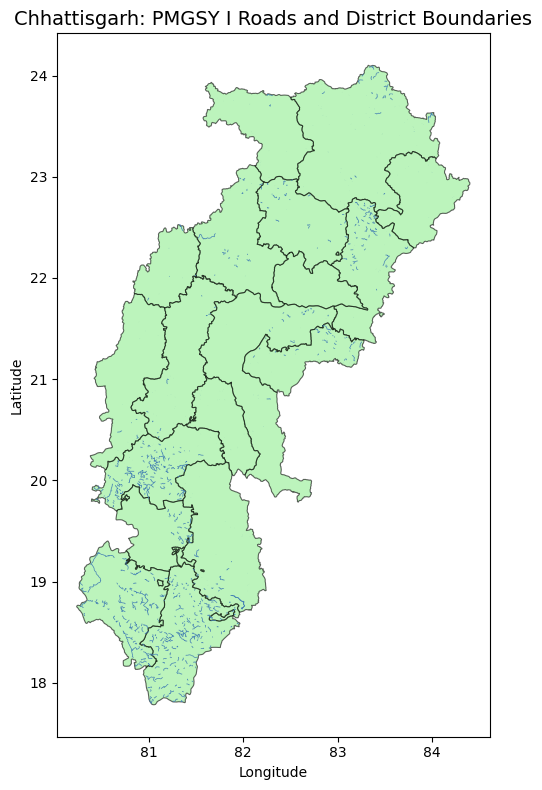

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot districts (green background)
Chhattisgarh_d.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
pmgsy1_roads.plot(ax=ax, color='steelblue', linewidth=0.5)

# Add title and clean layout
ax.set_title("Chhattisgarh: PMGSY I Roads and District Boundaries", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()
#District 400--- Koriya

# Ensure same CRS
pmgsy1_roads = pmgsy1_roads.to_crs(Chhattisgarh_d.crs)

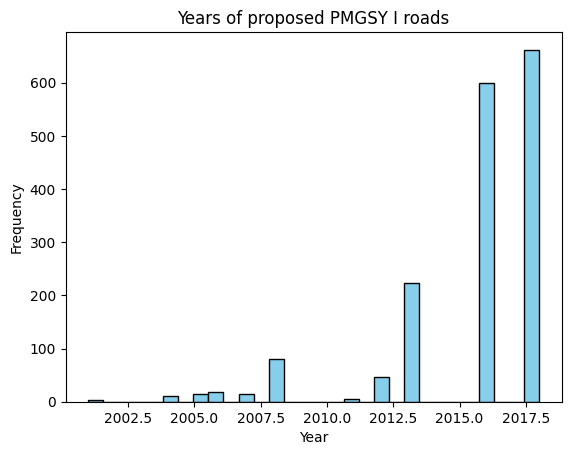

In [26]:
pmgsy1_roads["IMS_YEAR"].value_counts()
plt.hist(pmgsy1_roads["IMS_YEAR"], bins=30, color='skyblue', edgecolor='black') # You can customize the number of bins
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Years of proposed PMGSY I roads')
plt.show()

In [27]:
Chhattisgarh_d['pc11_d_id'] #dtype string 
pc11_key['pc11_district_id'] #dtype int
pc11_key['pc11_d_id'] = pc11_key['pc11_district_id'].astype(str)

In [28]:
#What we want: cross reference with shrid data on roads that villages got (pmgsy_shrid_cleaned), 
#but there are no measures of village in the pmgsy road data. SO we start with just matching district
pmgsy_shrid_clean.head()
#road_award_date_new, road_award_date_upg	road_comp_date_new road_sanc_year_new	
# road_sanc_year_upg	road_length_new	road_length_upg

#match pmgsy_shrid_clean with pc11_key that gives us the district

# first merge pc11_key with district.shp
#Chhattisgarh_d['pc11_d_id'] #dtype string 
#pc11_key['pc11_district_id'] #dtype int
pc11_key['pc11_d_id'] = pc11_key['pc11_district_id'].astype(str)
dist_geom= pc11_key.merge(Chhattisgarh_d, on='pc11_d_id')

# Match shrid value to district 
pmgsy_villages=pmgsy_shrid_clean.merge(dist_geom, on="shrid2")
#pmgsy_villages[pmgsy_villages["d_name"]=='Koriya']["road_name_new"].value_counts()
pmgsy_villages.head()

,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,...,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg,pc11_state_id,pc11_district_id,pc11_d_id,pc11_s_id,d_name,geometry
0,11-22-400-03231-431195,2008-10-01,NaN,2010-03-01,NaN,2009-10-28,NaN,2007.0,NaN,3.84,...,0.0,NaN,Madisarai - Mehdouli,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
1,11-22-400-03231-431197,2007-05-19,NaN,2008-06-01,NaN,2007-06-27,NaN,2006.0,NaN,4.35,...,0.0,NaN,T-07 Bela - Udaki,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
2,11-22-400-03231-431199,2008-02-27,NaN,2009-04-01,NaN,2009-04-02,NaN,2007.0,NaN,5.14,...,0.0,NaN,Ghughri - Goddhara,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
3,11-22-400-03231-431200,2013-08-28,NaN,2015-02-01,NaN,2014-09-23,NaN,2012.0,NaN,3.71,...,0.0,NaN,Madisarai - Karri,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
4,11-22-400-03231-431202,2013-02-12,NaN,2014-03-01,NaN,2013-03-15,NaN,2011.0,NaN,2.19,...,0.0,NaN,Jawaritola - Chhirhatola,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."


In [29]:
%pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
#plot overlapping village shrid ids and pmgsy I proposed roads based on district
p1_villages=pmgsy_villages.merge(pmgsy1_roads, left_on="pc11_district_id", right_on="LGD_DISTRI")
p1_villages.head()

,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,...,LGD_STATE,LGD_DISTRI,BLOCK_ID,CN_CODE,PROPOSED_L,WORK_NAME,IMS_YEAR,IMS_BATCH,Proposal_T,geometry_y


# Road Network of all of india 

✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 595438 entries, 0 to 595437
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   shrid2      595438 non-null  str     
 1   pc11_id     594139 non-null  str     
 2   n           594139 non-null  float64 
 3   geometry_t  594139 non-null  str     
 4   polysource  595438 non-null  str     
 5   n_ncontig   1299 non-null    float64 
 6   maxdist_km  1299 non-null    float64 
 7   geometry    595438 non-null  geometry
dtypes: float64(3), geometry(1), str(4)
memory usage: 36.3 MB
None


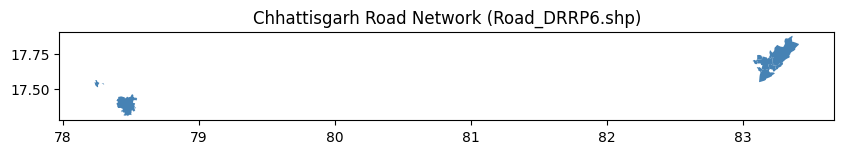

In [31]:
#need to join shrid2_open with state id from another shrid file 
#shrid2 are the village codes, what does pc11_id even mean?
shrid2_path = r"C:\Users\kavin\Downloads\Chhattisgarh_roads\shrug_data\shrug_data\shrug-shrid-poly-shp\shrid2_open.shp"

# Load the keys
shrid2_open =gpd.read_file(shrid2_path)
# Display basic info
print("✅ Shapefile loaded successfully!")
print(shrid2_open.info())

shrid2_chhat=shrid2_open.loc[(shrid2_open['pc11_id'] == "802947") | (shrid2_open['pc11_id'] == "802918")]
# Plot the shapefile
shrid2_chhat.plot(figsize=(10, 8), color='steelblue', linewidth=0.5)
plt.title("Chhattisgarh Road Network (Road_DRRP6.shp)")
plt.show()

In [32]:
#only choose Chhattisgarh shrid IDs 
shrid2_open #595438 rows
#chh_shrid_villages=pmgsy_villages['shrid2'].tolist()
#chh_shrid=shrid2_open[shrid2_open['shrid2'].isin(chh_shrid_villages)] #7613 rows

shrid2_open["state"] = shrid2_open["shrid2"].str.split("-").str[1]
cch_villages =shrid2_open[shrid2_open["state"]== '22']
cch_villages.head() #7613
#shrid2_open["state"].value_counts()

,shrid2,pc11_id,n,geometry_t,polysource,n_ncontig,maxdist_km,geometry,state
386498,11-22-400-03231-431192,431192,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((81.67317 23.92116, 81.67315 23.92034...",22
386499,11-22-400-03231-431193,431193,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((81.64942 23.89436, 81.64965 23.89374...",22
386500,11-22-400-03231-431194,431194,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((81.6428 23.87307, 81.64643 23.87106,...",22
386501,11-22-400-03231-431195,431195,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((81.68359 23.8812, 81.68425 23.8801, ...",22
386502,11-22-400-03231-431196,431196,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((81.69829 23.88118, 81.70072 23.88023...",22


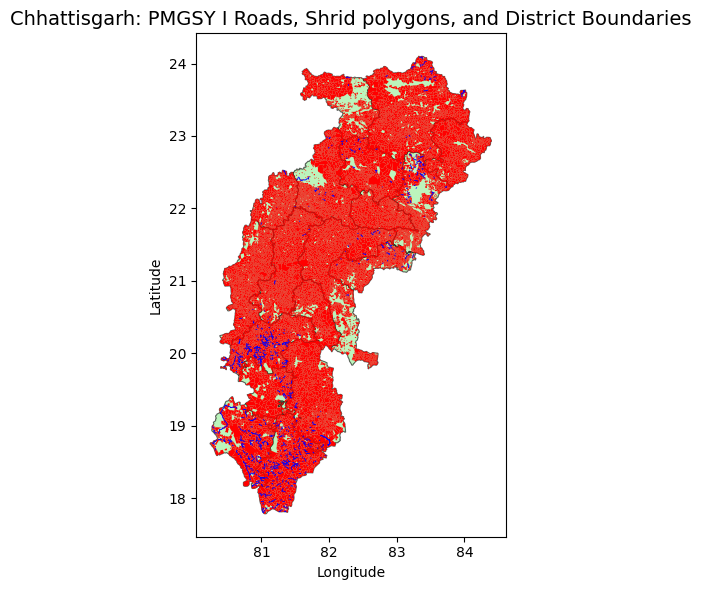

In [33]:
fig, ax = plt.subplots(figsize=(8,6))

# Plot districts (green background)
Chhattisgarh_d.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

#plot shrid villages
cch_villages.plot(ax=ax, color='red', linewidth=0.2)

# Plot roads (blue lines)
pmgsy1_roads.plot(ax=ax, color='blue', linewidth=0.6)


# Add title and clean layout
ax.set_title("Chhattisgarh: PMGSY I Roads, Shrid polygons, and District Boundaries", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Ensure same CRS
pmgsy1_roads = pmgsy1_roads.to_crs(Chhattisgarh_d.crs)

## Overlaps between Shrid villages and Pmgsy I roads

In [34]:
#make sure crs matches
cch_villages = cch_villages.to_crs(pmgsy1_roads.crs)

#spatial join
villages_with_roads = gpd.sjoin(
    cch_villages,
    pmgsy1_roads,
    predicate="intersects",
    how="inner"
)

# Get unique villages, Because one village might intersect multiple road segments:
pmgsy1_villages_unique = cch_villages.loc[villages_with_roads.index.unique()]

#count villages connected to roads
print(len(pmgsy1_villages_unique)) #1580

pmgsy1_villages=pmgsy1_villages_unique[["shrid2", "pc11_id", "n", "geometry", "state"]]
pmgsy1_villages.head() #villages served by pmgsy1 proposals

1580


,shrid2,pc11_id,n,geometry,state
386518,11-22-400-03231-431213,431213,1.0,"POLYGON ((81.78564 23.78737, 81.78567 23.78645...",22
386609,11-22-400-03231-431307,431307,1.0,"POLYGON ((81.80746 23.78496, 81.80828 23.78487...",22
386622,11-22-400-03231-431320,431320,1.0,"POLYGON ((81.93556 23.79331, 81.93964 23.79063...",22
386635,11-22-400-03231-431334,431334,1.0,"POLYGON ((82.06794 23.73593, 82.06829 23.73583...",22
386646,11-22-400-03231-431347,431347,1.0,"POLYGON ((82.29477 23.81344, 82.29445 23.81278...",22


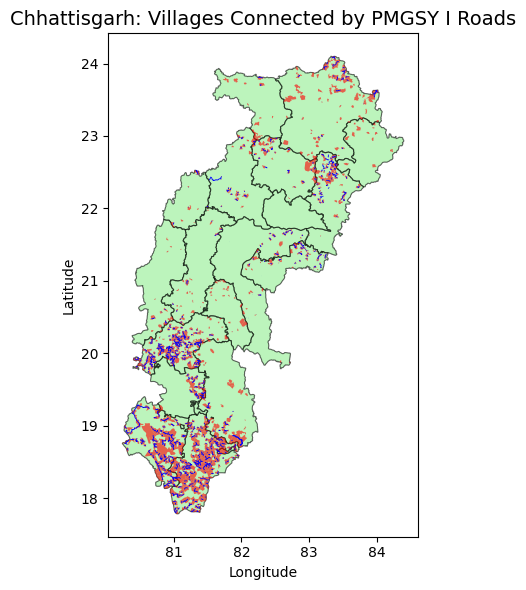

In [35]:
#graph it
fig, ax = plt.subplots(figsize=(8,6))

# Plot districts (green background)
Chhattisgarh_d.plot(ax=ax, color='lightgreen', edgecolor='black', linewidth=0.8, alpha=0.6)

#plot unique villages
pmgsy1_villages.plot(ax=ax, color='red', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
pmgsy1_roads.plot(ax=ax, color='blue', linewidth=0.6)

# Add title and clean layout
ax.set_title("Chhattisgarh: Villages Connected by PMGSY I Roads", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [36]:
pmgsy1_roads.head()
pmgsy_villages.head()

,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,...,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg,pc11_state_id,pc11_district_id,pc11_d_id,pc11_s_id,d_name,geometry
0,11-22-400-03231-431195,2008-10-01,NaN,2010-03-01,NaN,2009-10-28,NaN,2007.0,NaN,3.84,...,0.0,NaN,Madisarai - Mehdouli,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
1,11-22-400-03231-431197,2007-05-19,NaN,2008-06-01,NaN,2007-06-27,NaN,2006.0,NaN,4.35,...,0.0,NaN,T-07 Bela - Udaki,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
2,11-22-400-03231-431199,2008-02-27,NaN,2009-04-01,NaN,2009-04-02,NaN,2007.0,NaN,5.14,...,0.0,NaN,Ghughri - Goddhara,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
3,11-22-400-03231-431200,2013-08-28,NaN,2015-02-01,NaN,2014-09-23,NaN,2012.0,NaN,3.71,...,0.0,NaN,Madisarai - Karri,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
4,11-22-400-03231-431202,2013-02-12,NaN,2014-03-01,NaN,2013-03-15,NaN,2011.0,NaN,2.19,...,0.0,NaN,Jawaritola - Chhirhatola,NaN,22,400,400,22,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."


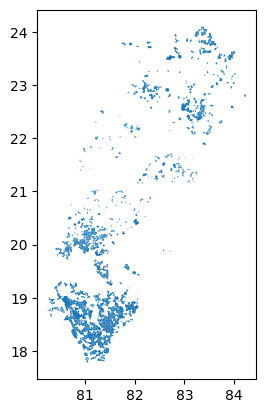

In [37]:
gdf = gpd.GeoDataFrame(pmgsy1_villages, geometry='geometry')

# Plot
gdf.plot()
plt.show()

In [ ]:
#graph it, color coded by year award date 
fig, ax = plt.subplots(figsize=(8,6))

# Plot districts (green background)
Chhattisgarh_d.plot(ax=ax, color='white', edgecolor='black', linewidth=0.8, alpha=0.6)


#plot unique villages
pmgsy1_villages.plot(ax=ax, color='red', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
pmgsy1_roads.plot(
    ax=ax,
    column="IMS_YEAR",
    cmap="viridis",        # choose a colormap
    edgecolor="black",
    linewidth=0.8,
    alpha=0.6,
    legend=True
)

# Add title and clean layout
ax.set_title("Chhattisgarh: Villages Connected by PMGSY I Roads", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## We have the villages that are matched with the PMGSY1 proposals and we need to figure out whether those proposals actually happened by looking at the village database that contains the first year that a pmgsy road got to that village which would be PMGSY1. 

We have the shrid values for the matched villages and we can merge those with the proposal year from PMGSY1 
Then we have the finished year from shred that we can match and say which roads were actually built and when.

In [ ]:
pmgsy_villages.columns

Index(['shrid2', 'road_award_date_new', 'road_award_date_upg',
       'road_comp_date_new', 'road_comp_date_upg', 'road_comp_date_stip_new',
       'road_comp_date_stip_upg', 'road_sanc_year_new', 'road_sanc_year_upg',
       'road_length_new', 'road_length_upg', 'road_cost_new', 'road_cost_upg',
       'road_cost_sanc_new', 'road_cost_sanc_upg', 'road_cost_state_new',
       'road_cost_state_upg', 'road_name_new', 'road_name_upg',
       'pc11_state_id', 'pc11_district_id', 'pc11_d_id', 'pc11_s_id', 'd_name',
       'geometry'],
      dtype='str')

In [ ]:
#villages shrid shapefile (shrid2_open) matched with pmgsy1 proposals ( has shrid2 and polygon )
pmgsy1_villages.head()

#pmgsy1 proposal (df has 2001 stateID, districtID, 2011 LGD_StateID, Proposed_Length, work_name, ims_year (i assume year proposed), and geometry)
pmgsy1_roads.head()
#p1_matched_roads.head()

#village shrid database with date of pmgsy road into village
pmgsy_villages.head() #initial df (has shrid2, road_award_date_new, road_comp_date_new, road_name_new, pc11_d_id	pc11_s_id	d_name	geometry)

#merge villages_unique with pmgsy village year data 
village_pmgsy1= pmgsy1_villages[['shrid2', 'pc11_id', 'n']].merge(
    pmgsy_villages[['shrid2', 'road_award_date_new', 'road_comp_date_new', 'road_name_new', 'd_name', 'geometry']],  on='shrid2',how='left')

village_pmgsy1 #1580
#485 rows of villages that were both matched with pmgsy1 proposals and to village database of first year roads got to the village

,shrid2,pc11_id,n,road_award_date_new,road_comp_date_new,road_name_new,d_name,geometry
0,11-22-400-03231-431213,431213,1.0,2008-10-01,2010-03-01,Bharatpur - Badkatola,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
1,11-22-400-03231-431307,431307,1.0,2007-05-19,2008-12-01,Barhori - Padari,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
2,11-22-400-03231-431320,431320,1.0,2013-08-28,NaN,NaN,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
3,11-22-400-03231-431334,431334,1.0,NaN,NaN,NaN,NaN,None
4,11-22-400-03231-431347,431347,1.0,2005-01-07,NaN,NaN,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034..."
...,...,...,...,...,...,...,...,...
1575,11-22-417-03379-451349,451349,1.0,NaN,NaN,NaN,NaN,None
1576,11-22-417-03379-451352,451352,1.0,NaN,NaN,NaN,NaN,None
1577,11-22-417-03379-802077,802077,1.0,NaN,NaN,NaN,NaN,None
1578,11-22-403-03267-801939,434920,3.0,2007-04-14,2008-03-01,Kosamnara - Kalmi,Raigarh,"MULTIPOLYGON (((83.00828 22.22487, 83.00771 22..."


# verify villages served by pmgsy1

## Road Name matches

In [ ]:
#rapidfuzz 
pmgsy_villages["road_name_new"].tolist()
pmgsy1_roads["WORK_NAME"].tolist()

['MAHAVIRGANJ SANAWAL ROAD KM 23 ROAD  - AABADI PASCHIMPARA',
 'L039-NH 6 to Dumarpali',
 'L064-NH 7 MAIN ROAD TO HATHOD',
 'L080-DANGANIYA TO GUREDA',
 'Kudal - Happra',
 'Mungwal - Bhaeja',
 'L081-dhanikodata to dengopara',
 'L026-8 KM OF BADGAON PRATAPUR ROAD BADEJHARKATTA',
 'L106-L-30 Kadme To Sodwapara Kadme',
 'INDRAPUR ROAD RD KM 1 - NEELKANTHPUR YADAVPARA',
 'L073-Binjam to Kotwarpara',
 'TATAPANI SARPANCHAPARA - KAPILDEOPUR MOSHAPARA',
 'L073-Binjam to Kotwarpara',
 'L028-12 KM OF KOILIBEDA PARTAPUR TO WALA',
 'T-05  - Rajkot',
 'L070-Turparas to Degalras',
 'L036-Gaytaparairpa to Pujariparairpa',
 'L070-Turparas to Degalras',
 'L048-NH 16 RD445 km to Korangali',
 'BANSPATTAR - RAWAS',
 'L127-L-52 Uliya To Tumaritola',
 'JAMGAON  - MANDRADARHA',
 'L030-TR 03 to Chiprikona',
 'Karpawand Garenga road RD 19 Km - Chargaon',
 'NH-16 RD 457.20 km.  - Pedapara Badekilepal',
 'L061-Motanpal Nakapara to Muskonta',
 'Alnar Kotwarpara - Khaspara Sidmur',
 'NH 43 ADWAL FOREST NAKA ROAD 3

In [ ]:
#can we match road names 
len(pmgsy1_roads["WORK_NAME"].tolist()) #gives 1676 road proposals in PMGSY I

common = set(village_pmgsy1["road_name_new"]) & set(pmgsy1_roads["WORK_NAME"])
len(common) #84 out of 1676
common = set(village_pmgsy1["road_name_new"]).intersection(set(pmgsy1_roads["WORK_NAME"]))
print(len(common))

50


In [ ]:
import re

def normalize(x):
    #if pd.isna(x):
        #return None
    x = str(x).lower()
    x = re.sub(r'[^a-z0-9 ]', '', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x
'''def normalize(x):
    x = x.lower()
    x = re.sub(r'[^a-z0-9 ]', '', x)   # remove punctuation
    x = re.sub(r'\s+', ' ', x).strip() # normalize spaces
    return x'''

roads_villages = [normalize(x) for x in village_pmgsy1["road_name_new"].dropna()]
roads_pmgsy = [normalize(x) for x in pmgsy1_roads["WORK_NAME"].dropna()]

matches = set(roads_villages).intersection(set(roads_pmgsy))
len(matches) #102 out of 1676
matches

# create normalized column
village_pmgsy1["road_name_norm"] = village_pmgsy1["road_name_new"].apply(normalize)

# filter rows where normalized value is in common
p1_matched_vills= village_pmgsy1[village_pmgsy1["road_name_norm"].isin(matches)]

# view matches (have matches with shrid)
p1_matched_vills #70 rows out of 7676 
#218 rows out of 1676 in shrid values table

<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\kavin\AppData\Local\Temp\ipykernel_29392\2296586593.py:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  x = re.sub(r'\s+', ' ', x).strip() # normalize spaces


,shrid2,pc11_id,n,road_award_date_new,road_comp_date_new,road_name_new,d_name,geometry,road_name_norm
8,11-22-400-03232-431399,431399,1.0,2007-04-02,2008-05-01,T07 - Dondibahra,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034...",t07 dondibahra
10,11-22-400-03234-431635,431635,1.0,2007-06-14,2008-12-01,Rojhi - Birouridand,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034...",rojhi birouridand
11,11-22-400-03234-431709,431709,1.0,2007-03-30,2008-05-01,T-03(KM11) - Siryakhoh,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034...",t03km11 siryakhoh
13,11-22-400-03235-431756,431756,1.0,2002-01-28,2004-03-01,Pondidi to Jarondha,Koriya,"POLYGON ((81.67317 23.92116, 81.67315 23.92034...",pondidi to jarondha
59,11-22-401-03237-431949,431949,1.0,2008-02-15,2014-01-01,TATAPANI SARPANCHAPARA - KAPILDEOPUR MOSHAPARA,Surguja,"POLYGON ((83.3424 24.09431, 83.34712 24.09354,...",tatapani sarpanchapara kapildeopur moshapara
...,...,...,...,...,...,...,...,...,...
705,11-22-413-03352-447913,447913,1.0,2006-01-31,2008-04-01,Masulpani MDR - Dumdum Bahra,Uttar Bastar Kanker,"POLYGON ((81.3361 20.55608, 81.33886 20.55602,...",masulpani mdr dumdum bahra
706,11-22-413-03352-447934,447934,1.0,2008-09-30,2010-07-01,JUNWANI TO DHEKUNA,Uttar Bastar Kanker,"POLYGON ((81.3361 20.55608, 81.33886 20.55602,...",junwani to dhekuna
957,11-22-414-03360-449105,449105,1.0,2010-04-22,2012-05-01,Alnar Kotwarpara - Khaspara Sidmur,Bastar,"MULTIPOLYGON (((81.89904 18.68152, 81.89959 18...",alnar kotwarpara khaspara sidmur
975,11-22-414-03364-449407,449407,1.0,2008-09-17,2013-03-01,Ratakhandipara(T01) - Talpara (Mailbeda),Bastar,"MULTIPOLYGON (((81.89904 18.68152, 81.89959 18...",ratakhandiparat01 talpara mailbeda


In [ ]:
pmgsy1_villages

,shrid2,pc11_id,n,geometry,state
386518,11-22-400-03231-431213,431213,1.0,"POLYGON ((81.78564 23.78737, 81.78567 23.78645...",22
386609,11-22-400-03231-431307,431307,1.0,"POLYGON ((81.80746 23.78496, 81.80828 23.78487...",22
386622,11-22-400-03231-431320,431320,1.0,"POLYGON ((81.93556 23.79331, 81.93964 23.79063...",22
386635,11-22-400-03231-431334,431334,1.0,"POLYGON ((82.06794 23.73593, 82.06829 23.73583...",22
386646,11-22-400-03231-431347,431347,1.0,"POLYGON ((82.29477 23.81344, 82.29445 23.81278...",22
...,...,...,...,...,...
406091,11-22-417-03379-451349,451349,1.0,"POLYGON ((81.18581 18.87277, 81.18658 18.87115...",22
406094,11-22-417-03379-451352,451352,1.0,"POLYGON ((81.16625 18.80577, 81.15395 18.80894...",22
406103,11-22-417-03379-802077,802077,1.0,"POLYGON ((81.06391 19.03244, 81.0701 19.03106,...",22
593574,11-22-403-03267-801939,434920,3.0,"POLYGON ((83.36005 21.89243, 83.3597 21.89373,...",22


In [ ]:
matched_shrid=p1_matched_vills[["shrid2"]] #pmgsy1_shrid_served
pmgsy1_shrid_served= pmgsy1_villages.merge(p1_matched_vills[["shrid2", "road_comp_date_new"]], on="shrid2", how="left")

pmgsy1_shrid_served['road_comp_date_new'].notna().sum() #70 hits 

np.int64(70)

In [ ]:
pmgsy1_shrid_served.to_csv('pmgsy1_shrid_served.csv', index=False)

## overlapping Shrid Goemetrys instead of Shrid2IDs?